# Part G: Gradient Descent from Scratch

## Objectives
- Understand Gradient Descent mathematically
- Implement Linear Regression from scratch using NumPy
- Create Cost Function (MSE)
- Derive Gradients
- Train using Gradient Descent
- Visualize Cost Convergence
- Compare with Scikit-Learn Linear Regression


## Mathematical Formulation

### Hypothesis Function
h(x) = θ₀ + θ₁x

### Cost Function (MSE)
J(θ) = (1/2m) Σ(h(x) - y)²

### Gradient Update Rules

θ₀ = θ₀ - α(1/m)Σ(h(x)-y)

θ₁ = θ₁ - α(1/m)Σ((h(x)-y)x)

Where:
- α = Learning Rate
- m = Number of Samples


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv('Advanced Regression HousePrice.csv')

df.head()


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [2]:
# Preprocessing

if 'sale_date' in df.columns:
    df['sale_date'] = pd.to_datetime(df['sale_date'])
    df['sale_year'] = df['sale_date'].dt.year
    df['sale_month'] = df['sale_date'].dt.month
    df.drop('sale_date', axis=1, inplace=True)

X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)


(3040, 12) (760, 12)


## Gradient Descent Implementation From Scratch

In [3]:
class GradientDescentLinearRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X, y):

        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0

        for epoch in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


In [4]:
gd_model = GradientDescentLinearRegression(
    learning_rate=0.01,
    epochs=1000
)

gd_model.fit(X_train, y_train)

gd_predictions = gd_model.predict(X_test)

gd_rmse = np.sqrt(mean_squared_error(y_test, gd_predictions))
gd_r2 = r2_score(y_test, gd_predictions)

print("Gradient Descent RMSE:", gd_rmse)
print("Gradient Descent R2 :", gd_r2)


Gradient Descent RMSE: 2570248.8699870887
Gradient Descent R2 : 0.917971498542671


## Cost Convergence Plot

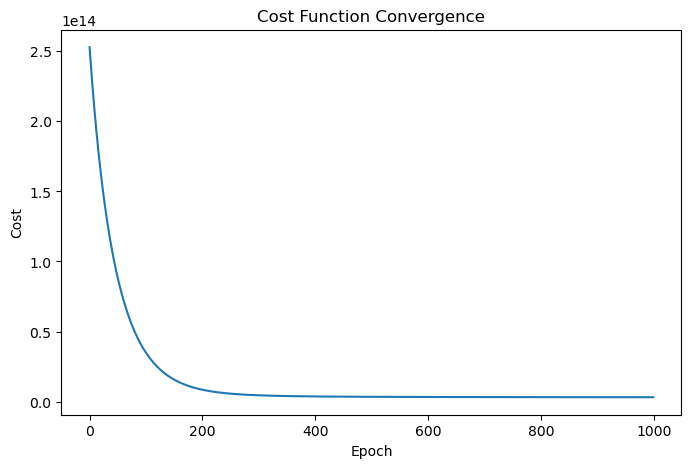

In [5]:
plt.figure(figsize=(8,5))
plt.plot(gd_model.cost_history)

plt.title('Cost Function Convergence')
plt.xlabel('Epoch')
plt.ylabel('Cost')

plt.show()


## Learning Rate Experiments

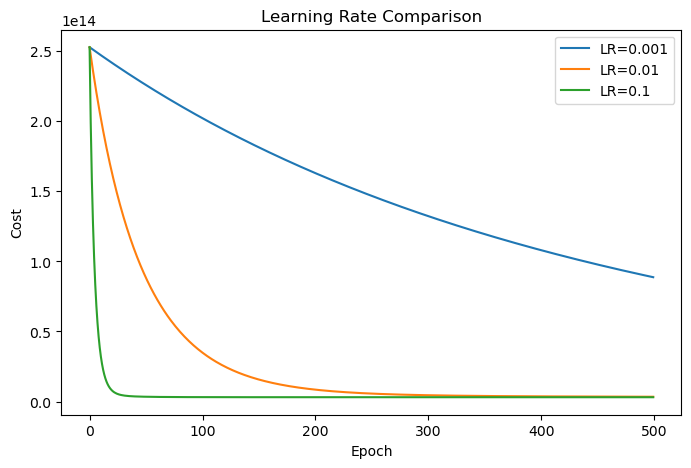

In [6]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    model = GradientDescentLinearRegression(
        learning_rate=lr,
        epochs=500
    )

    model.fit(X_train, y_train)

    plt.plot(
        model.cost_history,
        label=f'LR={lr}'
    )

plt.legend()
plt.title('Learning Rate Comparison')
plt.xlabel('Epoch')
plt.ylabel('Cost')

plt.show()


## Comparison with Scikit-Learn Linear Regression

In [7]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

comparison = pd.DataFrame({
    'Model':['Gradient Descent','Scikit-Learn Linear Regression'],
    'RMSE':[gd_rmse, lr_rmse],
    'R2':[gd_r2, lr_r2]
})

comparison


,Model,RMSE,R2
0,Gradient Descent,2.570249e+06,0.917971
1,Scikit-Learn Linear Regression,2.539836e+06,0.919901


In [8]:
comparison


,Model,RMSE,R2
0,Gradient Descent,2.570249e+06,0.917971
1,Scikit-Learn Linear Regression,2.539836e+06,0.919901


## Analysis

### Gradient Descent
- Iteratively updates parameters.
- Minimizes cost function.
- Learning rate controls convergence speed.

### Cost Convergence
- Decreasing cost indicates successful learning.
- Oscillating cost indicates high learning rate.

### Comparison
- Gradient Descent should approach the performance of Linear Regression.
- Scikit-Learn uses optimized solvers and is generally faster.

### Key Learning
Gradient Descent is the foundation of many Machine Learning and Deep Learning algorithms.


# Part G Completed

Deliverables:
- Mathematical Formulation
- Cost Function
- Gradient Derivation
- NumPy Implementation
- Cost Convergence Plot
- Learning Rate Experiments
- Comparison with Scikit-Learn
